<a href="https://colab.research.google.com/github/Edgar-Avila/006-machine-learning-algo-geneticos/blob/main/Actividad06_AG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_digits, load_wine
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

rng = np.random.default_rng(0)

In [14]:
# Motor generico de AG: representacion, inicializacion, aptitud, seleccion,
# cruzamiento, mutacion y terminacion (maximo de generaciones + elitismo)
def tournament(pop, fits, k=3):
    idx = rng.choice(len(pop), k, replace=False)
    return pop[idx[np.argmax([fits[i] for i in idx])]]

def one_point_cx(a, b):
    p = rng.integers(1, len(a))
    return a[:p] + b[p:], b[:p] + a[p:]

def run_ga(pop_size, gens, make_ind, fitness, mutate, cx=one_point_cx,
           cx_pb=0.8, mut_pb=0.2, elitism=2):
    pop = [make_ind() for _ in range(pop_size)]          # inicializacion
    fits = [fitness(ind) for ind in pop]                 # aptitud inicial
    hist = []
    for g in range(gens):                                # terminacion: max gens
        ordered = sorted(range(pop_size), key=lambda i: fits[i], reverse=True)
        new = [pop[i] for i in ordered[:elitism]]        # elitismo
        while len(new) < pop_size:
            a, b = tournament(pop, fits), tournament(pop, fits)   # seleccion
            if rng.random() < cx_pb:
                a, b = cx(a, b)                                   # cruzamiento
            a, b = mutate(a), mutate(b)                           # mutacion
            new += [a, b]
        pop = new[:pop_size]
        fits = [fitness(ind) for ind in pop]             # re-evaluacion
        hist.append(max(fits))
    best = pop[int(np.argmax(fits))]
    return best, max(fits), hist

In [16]:
def reporte(titulo, best, fit, hist):
    print(f"{titulo}")
    print(f"  mejor aptitud: {fit:.4f}")
    print(f"  mejor cromosoma: {best}")
    plt.figure(figsize=(6, 3))
    plt.plot(hist, marker="o")
    plt.title(f"{titulo} - evolucion de la aptitud")
    plt.xlabel("generacion")
    plt.ylabel("aptitud (mejor)")
    plt.show()

breast_cancer: (569, 30), 2 clases
Feature selection
  mejor aptitud: 0.9543
  mejor cromosoma: [1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0]


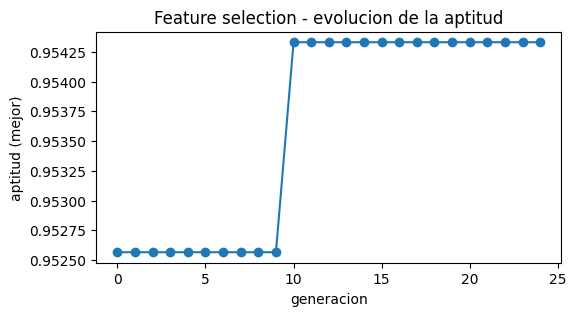

In [4]:
# 1) FEATURE SELECTION con breast_cancer (30 caracteristicas)
X, y = load_breast_cancer(return_X_y=True)
n_feat = X.shape[1]
print(f"breast_cancer: {X.shape}, {len(np.unique(y))} clases")

def fs_make():
    return [int(rng.random() < 0.5) for _ in range(n_feat)]

def fs_fitness(mask):
    if sum(mask) == 0:
        return 0.0
    Xs = X[:, np.array(mask, dtype=bool)]
    return cross_val_score(LogisticRegression(max_iter=2000), Xs, y, cv=3).mean()

def fs_mutate(a):
    if rng.random() < 0.2:
        i = rng.integers(n_feat)
        a = a[:i] + [1 - a[i]] + a[i + 1:]
    return a

fs_best, fs_fit, fs_hist = run_ga(14, 25, fs_make, fs_fitness, fs_mutate, mut_pb=0.2)
reporte("Feature selection", fs_best, fs_fit, fs_hist)

In [5]:
# Aptitud con todas las caracteristicas (referencia)
ref_fit = cross_val_score(LogisticRegression(max_iter=2000), X, y, cv=3).mean()
sel = np.array(fs_best, dtype=bool)
print(f"referencia (30 caracteristicas): {ref_fit:.4f}")
print(f"caracteristicas seleccionadas: {sel.sum()} de {n_feat}")
print(f"indices: {np.where(sel)[0].tolist()}")

referencia (30 caracteristicas): 0.9508
caracteristicas seleccionadas: 18 de 30
indices: [0, 1, 2, 4, 5, 7, 11, 12, 13, 15, 16, 17, 19, 21, 24, 26, 27, 28]


digits: (1797, 64), 10 clases
Hiperparametros SVC
  mejor aptitud: 0.9761
  mejor cromosoma: [np.float64(1.0532528537406516), np.float64(-3.003153646915031)]


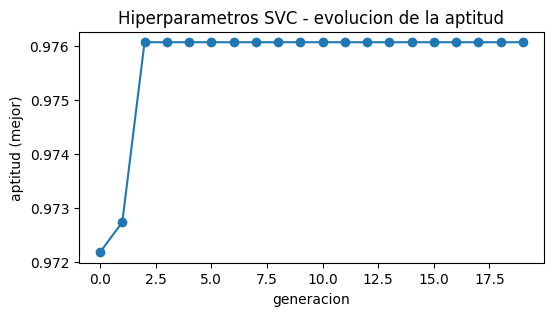

In [6]:
# 2) HIPERPARAMETER OPTIMIZATION de una SVC con digits (C y gamma en log10)
Xd, yd = load_digits(return_X_y=True)
print(f"digits: {Xd.shape}, {len(np.unique(yd))} clases")

def svm_make():
    return [rng.uniform(-1, 2), rng.uniform(-4, -1)]

def svm_fitness(g):
    c, gam = 10 ** g[0], 10 ** g[1]
    return cross_val_score(SVC(C=c, gamma=gam), Xd, yd, cv=3).mean()

def svm_mutate(a):
    out = list(a)
    for i in range(2):
        if rng.random() < 0.3:
            out[i] = np.clip(out[i] + rng.normal(0, 0.3), -4, 2)
    return out

svm_best, svm_fit, svm_hist = run_ga(12, 20, svm_make, svm_fitness, svm_mutate)
reporte("Hiperparametros SVC", svm_best, svm_fit, svm_hist)

In [7]:
# Hiperparametros encontrados (C, gamma)
print(f"C = {10 ** svm_best[0]:.3f}, gamma = {10 ** svm_best[1]:.5f}, acc = {svm_fit:.4f}")

C = 11.305, gamma = 0.00099, acc = 0.9761


digits: (1797, 64), 10 clases
Neuroevolution MLP
  mejor aptitud: 0.9232
  mejor cromosoma: [65, 43, np.float64(-2.1761882384818145)]


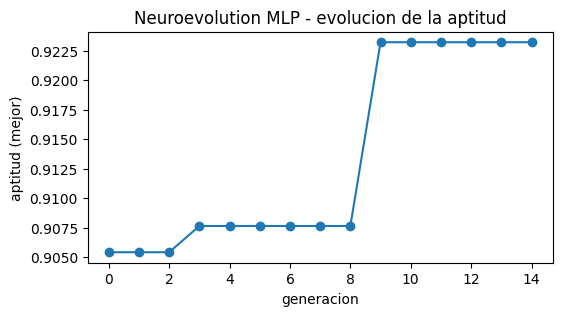

In [8]:
# 3) NEUROEVOLUTION: evolucion de la arquitectura de un MLP con digits
# cromosoma = [neuronas capa1, neuronas capa2 (0 = una sola capa), lr en log10]
Xw, yw = load_digits(return_X_y=True)
print(f"digits: {Xw.shape}, {len(np.unique(yw))} clases")

def mlp_make():
    return [int(rng.integers(10, 100)), int(rng.integers(0, 60)), rng.uniform(-4, -1)]

def mlp_fitness(g):
    h1, h2, lr = g[0], g[1], 10 ** g[2]
    hidden = (h1, h2) if h2 > 0 else (h1,)
    clf = MLPClassifier(hidden_layer_sizes=hidden, learning_rate_init=lr,
                        max_iter=300, early_stopping=True, random_state=0)
    return cross_val_score(clf, Xw, yw, cv=2).mean()

def mlp_mutate(a):
    out = list(a)
    if rng.random() < 0.3:
        out[0] = int(np.clip(out[0] + int(rng.normal(0, 8)), 10, 100))
    if rng.random() < 0.3:
        out[1] = int(np.clip(out[1] + int(rng.normal(0, 8)), 0, 60))
    if rng.random() < 0.3:
        out[2] = np.clip(out[2] + rng.normal(0, 0.3), -4, -1)
    return out

mlp_best, mlp_fit, mlp_hist = run_ga(10, 15, mlp_make, mlp_fitness, mlp_mutate)
reporte("Neuroevolution MLP", mlp_best, mlp_fit, mlp_hist)

In [9]:
# Arquitectura y tasa de aprendizaje evolucionadas
h1, h2, lr = mlp_best
hidden = (h1, h2) if h2 > 0 else (h1,)
print(f"arquitectura: {hidden}, lr = {10 ** lr:.4f}, acc = {mlp_fit:.4f}")

arquitectura: (65, 43), lr = 0.0067, acc = 0.9232
